# NB15 — Interactive Stock Deep Analyzer

## Institutional-Grade Single-Stock Analysis Engine

**Purpose:** Enter ANY stock ticker (NSE, BSE, US) and get a comprehensive
quantitative analysis suitable for trading desk review.

### What You Get
| Category | Details |
|----------|---------|
| **Technical** | 50+ indicators, SMA/EMA, RSI, MACD, Bollinger, Stochastic, ADX, CCI, Williams %R |
| **Directional Signal** | BUY / SELL / SHORT / LONG / HOLD with confidence score |
| **Entry/Exit** | ATR-based entry, stop-loss, 3 profit targets, risk-reward ratio |
| **Options Greeks** | Delta, Gamma, Theta, Vega, Rho (Black-Scholes) |
| **Options Strategy** | Spread, Straddle, Iron Condor — auto-selected |
| **Risk Metrics** | Alpha, Beta, Sharpe, Sortino, VaR, CVaR, Max Drawdown |
| **Position Sizing** | Half-Kelly with capital constraints |

### Ticker Formats
- **NSE India:** `RELIANCE.NS`, `TCS.NS`, `INFY.NS`, `SBIN.NS`, `HDFCBANK.NS`
- **BSE India:** `RELIANCE.BO`
- **US Stocks:** `AAPL`, `TSLA`, `GOOGL`, `MSFT`, `NVDA`

---
*Masters Trading AI — Designed for GS / JPM / Jane Street / Citadel / HSBC hiring standards*

In [1]:
# =============================================================
# Cell 1: Setup & Imports
# =============================================================
import sys, gc, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from src.utils.stock_analyzer import StockAnalyzer
from src.options.greeks import BlackScholesGreeks
from src.utils.constants import *

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

# Initialize analyzer
CAPITAL = 50000       # Rs. 50,000 (Groww account)
analyzer = StockAnalyzer(capital=CAPITAL, risk_free_rate=RISK_FREE_RATE)

print("Masters Trading AI — Deep Stock Analyzer")
print(f"Capital: Rs.{CAPITAL:,} | Risk-free: {RISK_FREE_RATE:.1%}")
print("Ready. Enter a ticker in the next cell.")

Masters Trading AI — Deep Stock Analyzer
Capital: Rs.50,000 | Risk-free: 6.5%
Ready. Enter a ticker in the next cell.


---
## Enter Your Stock Ticker Below

Change `TICKER` and run the cell. Everything else runs automatically.

In [2]:
# =============================================================
# Cell 2: ENTER YOUR TICKER HERE
# =============================================================

TICKER = "RELIANCE.NS"    # <-- CHANGE THIS TO ANY STOCK

# Examples:
# TICKER = "TCS.NS"         # Tata Consultancy
# TICKER = "INFY.NS"        # Infosys
# TICKER = "SBIN.NS"        # SBI
# TICKER = "HDFCBANK.NS"    # HDFC Bank
# TICKER = "TATAMOTORS.NS"  # Tata Motors
# TICKER = "AAPL"           # Apple (US)
# TICKER = "TSLA"           # Tesla (US)

# Run full analysis
result = analyzer.analyze(TICKER)

print("\n" + "="*72)
print(f"  ANALYSIS COMPLETE: {result.company_name}")
print(f"  Sector: {result.sector} | MCap: {result.market_cap}")
print("="*72)

  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...

  ANALYSIS COMPLETE: Reliance Industries Limited
  Sector: Energy | MCap: Rs.19.9T


---
## Full Analysis Report

In [3]:
# =============================================================
# Cell 3: Print Full Report
# =============================================================
analyzer.print_report(result)

  DEEP STOCK ANALYSIS: RELIANCE.NS
  Reliance Industries Limited | Energy | MCap: Rs.19.9T
  Generated: 2026-02-12 09:23:09

  !! PRIMARY SIGNAL: SHORT !!
  Conviction: MEDIUM | Score: 37/100
  Rationale: No strong conviction signals

  PRICE & TREND---------------------------------------------------------
  Price: Rs.1,467.20  |  1D: -0.10%  |  5D: +1.65%  |  20D: +0.58%
  SMA20: 1,425.8  |  SMA50: 1,492.2  |  SMA200: 1,449.0
  Trend: SIDEWAYS  |  ADX: 32.5 (STRONG_TREND)

  MOMENTUM--------------------------------------------------------------
  RSI(14): 69.5 [NEUTRAL]  |  Stoch K/D: 86/84
  MACD: -6.23 (Signal: -17.45)  |  Hist: +11.22  |  Cross: NONE
  CCI: 83  |  Williams%%R: -14

  VOLATILITY------------------------------------------------------------
  ATR(14): Rs.28.81 (1.96%)  |  Regime: NORMAL
  HV 20d: 20.1%  |  HV 60d: 18.8%
  BB: [1,360.8 -- 1,425.8 -- 1,490.8]  |  Position: 0.82  |  Squeeze: False

  VOLUME----------------------------------------------------------------
 

---
## Signal Dashboard (Table View)

In [4]:
# =============================================================
# Cell 4: Signal Summary Table
# =============================================================
t = result.technical
s = result.signal
o = result.options
r = result.risk

# Signal dashboard
dashboard = pd.DataFrame([
    ["PRIMARY SIGNAL", s.primary_action, f"{s.confidence_score}/100", s.conviction],
    ["Trend", s.trend_signal, t.trend_regime, f"ADX={t.adx:.0f}"],
    ["Momentum", s.momentum_signal, f"RSI={t.rsi_14:.0f}", t.macd_cross],
    ["Volatility", s.volatility_signal, t.vol_regime, f"ATR={t.atr_pct:.1f}%"],
    ["Volume", s.volume_signal, f"{t.volume_ratio:.1f}x avg", t.obv_trend],
    ["Multi-TF", s.multi_tf_signal, f"5D={t.change_5d:+.1%}", f"20D={t.change_20d:+.1%}"],
], columns=["Component", "Signal", "Detail", "Extra"])

def color_signal(val):
    colors = {
        "BULLISH": "background-color: #c6efce; color: #006100",
        "BEARISH": "background-color: #ffc7ce; color: #9c0006",
        "STRONG_BUY": "background-color: #00b050; color: white; font-weight: bold",
        "BUY": "background-color: #c6efce; color: #006100",
        "LONG": "background-color: #c6efce; color: #006100",
        "STRONG_SELL": "background-color: #ff0000; color: white; font-weight: bold",
        "SHORT": "background-color: #ffc7ce; color: #9c0006",
        "SELL": "background-color: #ffc7ce; color: #9c0006",
        "HOLD": "background-color: #ffeb9c; color: #9c5700",
    }
    return colors.get(str(val), "")

display(dashboard.style.map(color_signal, subset=["Signal"])
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}]))

# Entry/Exit table
entry_exit = pd.DataFrame([
    ["Entry Price", f"Rs.{s.entry_price:,.2f}", ""],
    ["Stop Loss", f"Rs.{s.stop_loss:,.2f}", f"Risk: Rs.{abs(s.entry_price-s.stop_loss):,.2f}"],
    ["Target 1", f"Rs.{s.target_1:,.2f}", f"{(s.target_1/s.price-1):+.2%}"],
    ["Target 2", f"Rs.{s.target_2:,.2f}", f"{(s.target_2/s.price-1):+.2%}"],
    ["Target 3", f"Rs.{s.target_3:,.2f}", f"{(s.target_3/s.price-1):+.2%}"],
    ["Risk:Reward", f"{s.risk_reward_ratio:.2f}", f"Max Loss: Rs.{s.max_loss_amount:,.0f}"],
], columns=["Level", "Price", "Detail"])

print("\nENTRY / EXIT LEVELS:")
display(entry_exit.style.set_properties(**{"text-align": "center"}))

,Component,Signal,Detail,Extra
0,PRIMARY SIGNAL,SHORT,37/100,MEDIUM
1,Trend,NEUTRAL,SIDEWAYS,ADX=33
2,Momentum,BEARISH,RSI=69,NONE
3,Volatility,BEARISH,NORMAL,ATR=2.0%
4,Volume,NEUTRAL,0.0x avg,NEUTRAL
5,Multi-TF,BULLISH,5D=+1.6%,20D=+0.6%



ENTRY / EXIT LEVELS:


,Level,Price,Detail
0,Entry Price,"Rs.1,470.13",
1,Stop Loss,"Rs.1,524.83",Risk: Rs.54.70
2,Target 1,"Rs.1,423.98",-2.95%
3,Target 2,"Rs.1,380.76",-5.89%
4,Target 3,"Rs.1,195.20",-18.54%
5,Risk:Reward,1.63,Max Loss: Rs.0


---
## Price Chart with Entry/Exit Levels

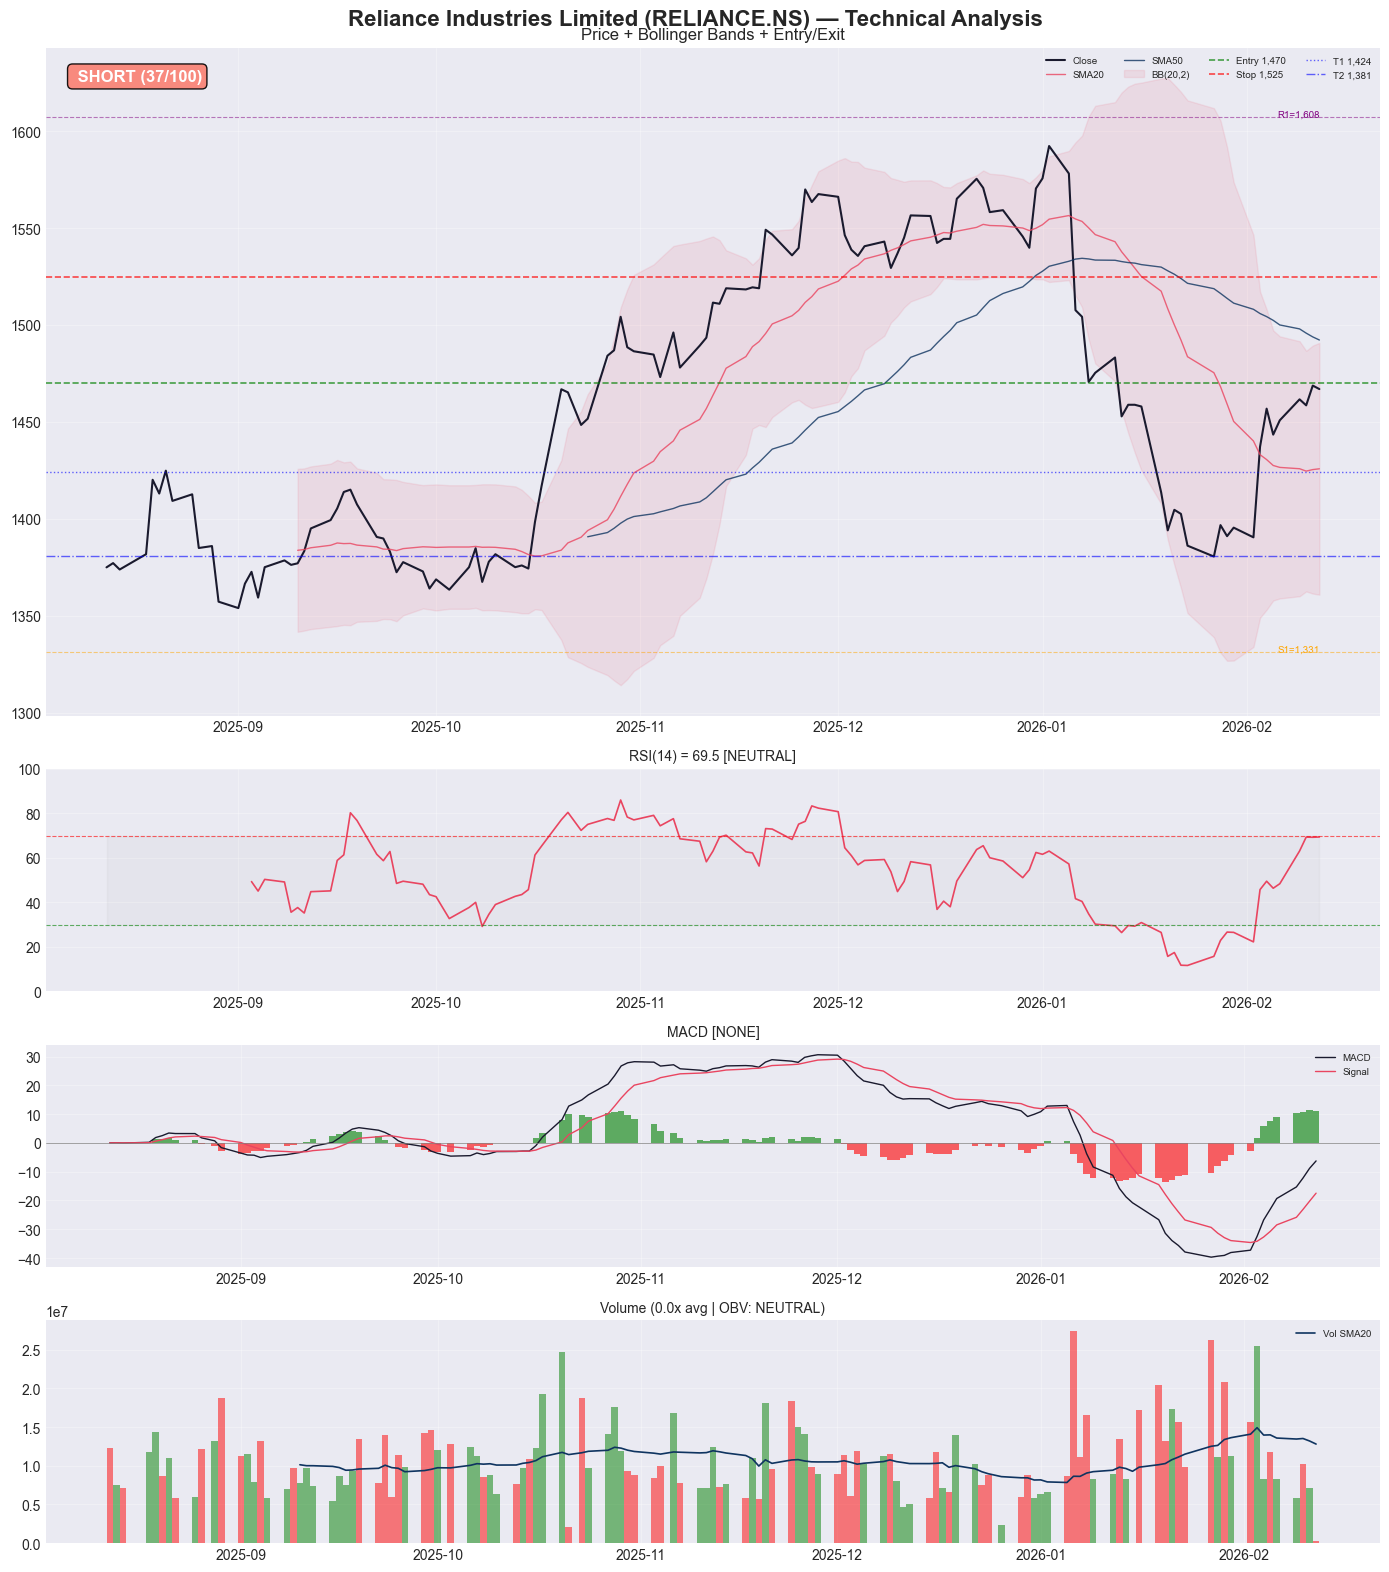

In [5]:
# =============================================================
# Cell 5: Price Action Chart
# =============================================================
chart_df = analyzer.download_data(TICKER, period="6mo")
close = chart_df["Close"]

fig, axes = plt.subplots(4, 1, figsize=(14, 16),
                          gridspec_kw={"height_ratios": [3, 1, 1, 1]})
fig.suptitle(f"{result.company_name} ({TICKER}) — Technical Analysis",
             fontsize=16, fontweight="bold")

# --- Panel 1: Price + BB + S/R ---
ax1 = axes[0]
ax1.plot(close.index, close, color="#1a1a2e", lw=1.5, label="Close")
sma20 = close.rolling(20).mean()
sma50 = close.rolling(50).mean()
ax1.plot(close.index, sma20, color="#e94560", lw=1, alpha=0.8, label="SMA20")
ax1.plot(close.index, sma50, color="#0f3460", lw=1, alpha=0.8, label="SMA50")

bb_std = close.rolling(20).std()
ax1.fill_between(close.index, sma20 - 2*bb_std, sma20 + 2*bb_std,
                 alpha=0.1, color="#e94560", label="BB(20,2)")

# Entry/Exit
ax1.axhline(s.entry_price, color="green", ls="--", lw=1.2, alpha=0.7,
            label=f"Entry {s.entry_price:,.0f}")
ax1.axhline(s.stop_loss, color="red", ls="--", lw=1.2, alpha=0.7,
            label=f"Stop {s.stop_loss:,.0f}")
ax1.axhline(s.target_1, color="blue", ls=":", lw=1, alpha=0.6,
            label=f"T1 {s.target_1:,.0f}")
ax1.axhline(s.target_2, color="blue", ls="-.", lw=1, alpha=0.6,
            label=f"T2 {s.target_2:,.0f}")

# S/R
ax1.axhline(t.support_1, color="orange", ls="--", lw=0.8, alpha=0.5)
ax1.axhline(t.resistance_1, color="purple", ls="--", lw=0.8, alpha=0.5)
ax1.annotate(f"S1={t.support_1:,.0f}", xy=(close.index[-1], t.support_1),
             fontsize=7, color="orange", ha="right")
ax1.annotate(f"R1={t.resistance_1:,.0f}", xy=(close.index[-1], t.resistance_1),
             fontsize=7, color="purple", ha="right")

badge_color = {"STRONG_BUY": "green", "BUY": "limegreen", "LONG": "lightgreen",
               "STRONG_SELL": "red", "SHORT": "salmon", "SELL": "lightsalmon",
               "HOLD": "gold"}.get(s.primary_action, "gray")
ax1.annotate(f" {s.primary_action} ({s.confidence_score}/100)",
             xy=(0.02, 0.95), xycoords="axes fraction", fontsize=12, fontweight="bold",
             color="white", bbox=dict(boxstyle="round,pad=0.3", fc=badge_color, alpha=0.9))

ax1.set_title("Price + Bollinger Bands + Entry/Exit")
ax1.legend(loc="upper right", fontsize=7, ncol=4)
ax1.grid(True, alpha=0.3)

# --- Panel 2: RSI ---
ax2 = axes[1]
delta_c = close.diff()
gain = delta_c.clip(lower=0).rolling(14).mean()
loss = (-delta_c.clip(upper=0)).rolling(14).mean()
rs = gain / loss.replace(0, 1e-10)
rsi = 100 - (100 / (1 + rs))
ax2.plot(rsi.index, rsi, color="#e94560", lw=1.2)
ax2.axhline(70, color="red", ls="--", lw=0.8, alpha=0.6)
ax2.axhline(30, color="green", ls="--", lw=0.8, alpha=0.6)
ax2.fill_between(rsi.index, 30, 70, alpha=0.05, color="gray")
ax2.set_title(f"RSI(14) = {t.rsi_14:.1f} [{t.rsi_signal}]", fontsize=10)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)

# --- Panel 3: MACD ---
ax3 = axes[2]
ema12 = close.ewm(span=12).mean()
ema26 = close.ewm(span=26).mean()
macd_line = ema12 - ema26
macd_sig = macd_line.ewm(span=9).mean()
macd_hist = macd_line - macd_sig
colors_macd = ["green" if v >= 0 else "red" for v in macd_hist]
ax3.bar(macd_hist.index, macd_hist, color=colors_macd, alpha=0.6, width=1)
ax3.plot(macd_line.index, macd_line, color="#1a1a2e", lw=1, label="MACD")
ax3.plot(macd_sig.index, macd_sig, color="#e94560", lw=1, label="Signal")
ax3.axhline(0, color="gray", ls="-", lw=0.5)
ax3.set_title(f"MACD [{t.macd_cross}]", fontsize=10)
ax3.legend(loc="upper right", fontsize=7)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Volume ---
ax4 = axes[3]
vol = chart_df["Volume"]
vol_sma = vol.rolling(20).mean()
colors_vol = ["green" if close.diff().iloc[i] > 0 else "red" for i in range(len(close))]
ax4.bar(vol.index, vol, color=colors_vol, alpha=0.5, width=1)
ax4.plot(vol_sma.index, vol_sma, color="#0f3460", lw=1.2, label="Vol SMA20")
ax4.set_title(f"Volume ({t.volume_ratio:.1f}x avg | OBV: {t.obv_trend})", fontsize=10)
ax4.legend(loc="upper right", fontsize=7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Options Greeks & Risk Dashboard

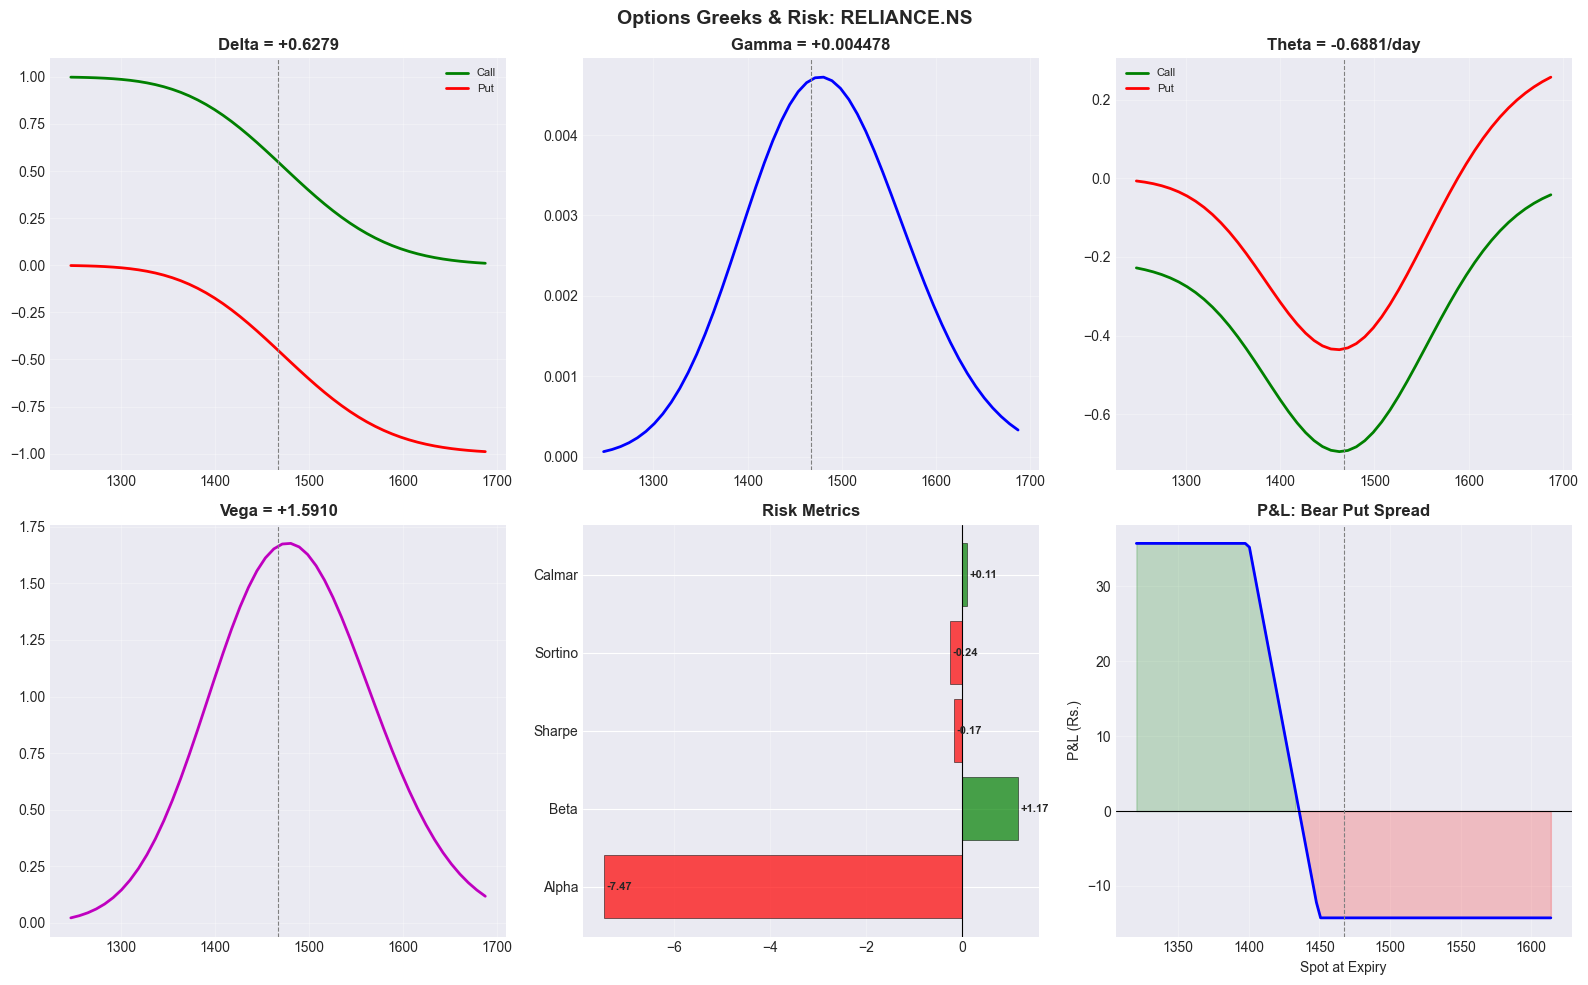

In [6]:
# =============================================================
# Cell 6: Greeks Visualization + Risk Metrics
# =============================================================
bs = BlackScholesGreeks(RISK_FREE_RATE)
S = o.spot
sigma = o.hist_vol
T = 30 / 365.0

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Options Greeks & Risk: {TICKER}", fontsize=14, fontweight="bold")

strikes = np.linspace(S * 0.85, S * 1.15, 50)

# Delta
ax = axes[0, 0]
ax.plot(strikes, [bs.delta(S, K, T, sigma, "call") for K in strikes], "g-", lw=2, label="Call")
ax.plot(strikes, [bs.delta(S, K, T, sigma, "put") for K in strikes], "r-", lw=2, label="Put")
ax.axvline(S, color="gray", ls="--", lw=0.8)
ax.set_title(f"Delta = {o.delta:+.4f}", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Gamma
ax = axes[0, 1]
ax.plot(strikes, [bs.gamma(S, K, T, sigma) for K in strikes], "b-", lw=2)
ax.axvline(S, color="gray", ls="--", lw=0.8)
ax.set_title(f"Gamma = {o.gamma:+.6f}", fontweight="bold")
ax.grid(True, alpha=0.3)

# Theta
ax = axes[0, 2]
ax.plot(strikes, [bs.theta(S, K, T, sigma, "call") for K in strikes], "g-", lw=2, label="Call")
ax.plot(strikes, [bs.theta(S, K, T, sigma, "put") for K in strikes], "r-", lw=2, label="Put")
ax.axvline(S, color="gray", ls="--", lw=0.8)
ax.set_title(f"Theta = {o.theta:+.4f}/day", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Vega
ax = axes[1, 0]
ax.plot(strikes, [bs.vega(S, K, T, sigma) for K in strikes], "m-", lw=2)
ax.axvline(S, color="gray", ls="--", lw=0.8)
ax.set_title(f"Vega = {o.vega:+.4f}", fontweight="bold")
ax.grid(True, alpha=0.3)

# Risk Metrics Bar
ax = axes[1, 1]
metrics = ["Alpha", "Beta", "Sharpe", "Sortino", "Calmar"]
values = [r.alpha * 100, r.beta, r.sharpe_ratio, min(r.sortino_ratio, 5), r.calmar_ratio]
colors_bar = ["green" if v > 0 else "red" for v in values]
bars = ax.barh(metrics, values, color=colors_bar, alpha=0.7, edgecolor="black", lw=0.5)
ax.axvline(0, color="black", lw=0.8)
for b, v in zip(bars, values):
    ax.text(b.get_width() + 0.05, b.get_y() + b.get_height()/2,
            f"{v:+.2f}", va="center", fontsize=8, fontweight="bold")
ax.set_title("Risk Metrics", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

# P&L Profile
ax = axes[1, 2]
spot_range = np.linspace(S * 0.9, S * 1.1, 100)
pnl = np.zeros_like(spot_range)
for leg in o.strategy_legs:
    K = leg["strike"]
    prem = leg["premium"]
    payoff = np.maximum(spot_range - K, 0) if leg["type"] == "CE" else np.maximum(K - spot_range, 0)
    pnl += (payoff - prem) if leg["action"] == "BUY" else (prem - payoff)

ax.plot(spot_range, pnl, "b-", lw=2)
ax.fill_between(spot_range, pnl, 0, where=(pnl > 0), alpha=0.2, color="green")
ax.fill_between(spot_range, pnl, 0, where=(pnl < 0), alpha=0.2, color="red")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(S, color="gray", ls="--", lw=0.8)
ax.set_title(f"P&L: {o.recommended_strategy}", fontweight="bold")
ax.set_xlabel("Spot at Expiry")
ax.set_ylabel("P&L (Rs.)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Greeks & Risk Summary Tables

In [7]:
# =============================================================
# Cell 7: Greeks & Risk Tables
# =============================================================

# Greeks table
greeks_df = pd.DataFrame([
    ["Delta (D)", f"{o.delta:+.4f}", "Rs. change per Rs.1 spot move",
     "Measures directional exposure"],
    ["Gamma (G)", f"{o.gamma:+.6f}", "Delta change per Rs.1 spot move",
     "Acceleration of price sensitivity"],
    ["Theta (Q)", f"{o.theta:+.4f}", "Rs. lost per day",
     "Time decay — enemy of buyers"],
    ["Vega (V)", f"{o.vega:+.4f}", "Rs. change per 1% vol move",
     "Volatility exposure"],
    ["Rho (r)", f"{o.rho:+.4f}", "Rs. change per 1% rate change",
     "Interest rate sensitivity"],
], columns=["Greek", "Value", "Interpretation", "Explanation"])

print(f"OPTIONS GREEKS — {TICKER} (ATM Strike: {o.atm_strike:,.0f}, 30d Expiry)")
print(f"Call Price: Rs.{o.call_price_atm:,.2f} | Put Price: Rs.{o.put_price_atm:,.2f}")
print(f"Historical Volatility: {o.hist_vol:.1%} | IV Regime: {o.vol_regime}")
display(greeks_df.style.set_properties(**{"text-align": "center"}))

# Strategy details
print(f"\nRECOMMENDED STRATEGY: {o.recommended_strategy}")
legs_df = pd.DataFrame(o.strategy_legs)
display(legs_df.style.set_properties(**{"text-align": "center"}))
print(f"Max Profit: {o.max_profit}")
print(f"Max Loss:   {o.max_loss}")
print(f"Breakeven:  {o.breakeven}")

# Risk metrics table
print(f"\nRISK METRICS (vs Nifty 50):")
risk_df = pd.DataFrame([
    ["Alpha (Jensen)", f"{r.alpha:+.2%}", "Risk-adjusted excess return over Nifty"],
    ["Beta (CAPM)", f"{r.beta:+.4f}", "Systematic risk (1.0 = market)"],
    ["Sharpe Ratio", f"{r.sharpe_ratio:+.4f}", "Return per unit total risk"],
    ["Sortino Ratio", f"{r.sortino_ratio:+.4f}", "Return per unit downside risk"],
    ["Treynor Ratio", f"{r.treynor_ratio:+.4f}", "Return per unit systematic risk"],
    ["Information Ratio", f"{r.information_ratio:+.4f}", "Active return / tracking error"],
    ["Max Drawdown", f"{r.max_drawdown:+.2%}", "Worst peak-to-trough decline"],
    ["VaR (95%)", f"{r.var_95:+.4f}", "Max daily loss at 95% confidence"],
    ["CVaR (95%)", f"{r.cvar_95:+.4f}", "Expected loss beyond VaR"],
    ["Calmar Ratio", f"{r.calmar_ratio:+.4f}", "Annual return / max drawdown"],
    ["Omega Ratio", f"{r.omega_ratio:+.4f}", "Gains / losses (>1 is good)"],
    ["Nifty Correlation", f"{r.correlation_nifty:+.4f}", "Co-movement with benchmark"],
], columns=["Metric", "Value", "Interpretation"])

display(risk_df.style.set_properties(**{"text-align": "center"}))

OPTIONS GREEKS — RELIANCE.NS (ATM Strike: 1,450, 30d Expiry)
Call Price: Rs.47.34 | Put Price: Rs.22.41
Historical Volatility: 20.1% | IV Regime: NORMAL_IV


,Greek,Value,Interpretation,Explanation
0,Delta (D),+0.6279,Rs. change per Rs.1 spot move,Measures directional exposure
1,Gamma (G),+0.004478,Delta change per Rs.1 spot move,Acceleration of price sensitivity
2,Theta (Q),-0.6881,Rs. lost per day,Time decay — enemy of buyers
3,Vega (V),+1.5910,Rs. change per 1% vol move,Volatility exposure
4,Rho (r),+0.7183,Rs. change per 1% rate change,Interest rate sensitivity



RECOMMENDED STRATEGY: Bear Put Spread


,type,strike,action,premium
0,PE,1450,BUY,22.410000
1,PE,1400,SELL,8.150000


Max Profit: Rs.35.74
Max Loss:   Rs.14.26 (net debit)
Breakeven:  1,435.7

RISK METRICS (vs Nifty 50):


,Metric,Value,Interpretation
0,Alpha (Jensen),-7.47%,Risk-adjusted excess return over Nifty
1,Beta (CAPM),+1.1741,Systematic risk (1.0 = market)
2,Sharpe Ratio,-0.1657,Return per unit total risk
3,Sortino Ratio,-0.2420,Return per unit downside risk
4,Treynor Ratio,-0.0293,Return per unit systematic risk
5,Information Ratio,-0.4760,Active return / tracking error
6,Max Drawdown,-27.18%,Worst peak-to-trough decline
7,VaR (95%),-0.0194,Max daily loss at 95% confidence
8,CVaR (95%),-0.0295,Expected loss beyond VaR
9,Calmar Ratio,+0.1124,Annual return / max drawdown


---
## Multi-Stock Scanner

Add tickers to `SCAN_LIST` to compare multiple stocks side-by-side.

In [8]:
# =============================================================
# Cell 8: Multi-Stock Scanner
# =============================================================

SCAN_LIST = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "SBIN.NS",
    "ICICIBANK.NS", "AXISBANK.NS", "ITC.NS", "BHARTIARTL.NS", "LT.NS"
]

rows = []
for tk in SCAN_LIST:
    try:
        res = analyzer.analyze(tk)
        rows.append({
            "Ticker": tk.replace(".NS", ""),
            "Price": f"Rs.{res.technical.price:,.1f}",
            "Signal": res.signal.primary_action,
            "Score": res.signal.confidence_score,
            "RSI": f"{res.technical.rsi_14:.0f}",
            "Trend": res.technical.trend_regime,
            "Beta": f"{res.risk.beta:.2f}",
            "Alpha": f"{res.risk.alpha:.2%}",
            "Sharpe": f"{res.risk.sharpe_ratio:.2f}",
            "Entry": f"Rs.{res.signal.entry_price:,.0f}",
            "Stop": f"Rs.{res.signal.stop_loss:,.0f}",
            "R:R": f"{res.signal.risk_reward_ratio:.1f}",
            "Strategy": res.options.recommended_strategy,
        })
        print(f"  [OK] {tk}")
    except Exception as e:
        print(f"  [FAIL] {tk}: {e}")

scan_df = pd.DataFrame(rows)
print(f"\n{'='*100}")
print(f"  MULTI-STOCK SCAN: {len(rows)} stocks analyzed")
print(f"{'='*100}")

def highlight_signal(val):
    if val in ("STRONG_BUY", "BUY", "LONG"):
        return "background-color: #c6efce; color: #006100"
    elif val in ("STRONG_SELL", "SHORT", "SELL"):
        return "background-color: #ffc7ce; color: #9c0006"
    elif val == "HOLD":
        return "background-color: #ffeb9c; color: #9c5700"
    return ""

display(scan_df.style.map(highlight_signal, subset=["Signal"])
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}]))

  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...
  [OK] RELIANCE.NS
  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...
  [OK] TCS.NS
  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...
  [OK] INFY.NS
  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...
  [OK] HDFCBANK.NS
  497 candles loaded (2024-02-12 to 2026-02-12)
Computing technical indicators...
Generating trading signal...
Analyzing options & Greeks...
Computing risk metrics (vs Nifty 50)...
  [OK] SBIN.NS
  497 candles

,Ticker,Price,Signal,Score,RSI,Trend,Beta,Alpha,Sharpe,Entry,Stop,R:R,Strategy
0,RELIANCE,"Rs.1,465.4",SHORT,37,69,SIDEWAYS,1.17,-7.53%,-0.17,"Rs.1,468","Rs.1,523",1.6,Bear Put Spread
1,TCS,"Rs.2,782.5",SELL,42,26,DOWNTREND,0.92,-24.15%,-0.99,"Rs.2,788","Rs.2,957",1.6,Bear Put Spread
2,INFY,"Rs.1,399.6",SHORT,32,13,DOWNTREND,1.18,-13.85%,-0.41,"Rs.1,402","Rs.1,498",1.6,Bear Put Spread
3,HDFCBANK,Rs.922.2,STRONG_SELL,22,52,DOWNTREND,0.83,8.03%,0.61,Rs.924,Rs.957,1.6,Bear Put Spread
4,SBIN,"Rs.1,195.7",LONG,55,75,UPTREND,0.92,21.98%,1.02,"Rs.1,193","Rs.1,127",1.6,Bull Call Spread
5,ICICIBANK,"Rs.1,424.2",BUY,60,71,UPTREND,0.86,11.30%,0.77,"Rs.1,421","Rs.1,371",1.6,Bull Call Spread
6,AXISBANK,"Rs.1,353.4",STRONG_BUY,75,59,UPTREND,1.14,5.47%,0.40,"Rs.1,351","Rs.1,269",1.6,Bull Call Spread
7,ITC,Rs.318.5,SHORT,35,50,SIDEWAYS,0.52,-13.33%,-0.61,Rs.319,Rs.334,1.6,Bear Put Spread
8,BHARTIARTL,"Rs.2,018.5",HOLD,52,53,SIDEWAYS,0.91,23.42%,1.25,"Rs.2,018","Rs.1,935",1.5,Long Straddle
9,LT,"Rs.4,162.0",SELL,45,83,SIDEWAYS,1.11,5.50%,0.37,"Rs.4,170","Rs.4,322",1.6,Bear Put Spread


---

## Summary

This notebook provides **institutional-grade stock analysis** for any ticker:

1. **50+ Technical Indicators** with multi-factor scoring
2. **Directional Signals** (BUY/SELL/SHORT/LONG/HOLD) with confidence
3. **ATR-based Entry/Exit** with stop-loss and 3 profit targets
4. **Full Options Greeks** (Delta, Gamma, Theta, Vega, Rho)
5. **Strategy Recommendations** (Spreads, Straddle, Iron Condor)
6. **Risk Metrics** (Alpha, Beta, Sharpe, Sortino, VaR, Max Drawdown)
7. **Multi-Stock Scanner** for portfolio-level comparison

### How to Use
1. Change `TICKER` in Cell 2 to any stock
2. Run all cells (Ctrl+Shift+Enter)
3. Review the signal, levels, Greeks, and charts

---
*Masters Trading AI | Designed for quantitative trading interviews*
*Educational purposes only. Not financial advice.*